In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

## Load Results CSV

In [2]:
results_path = "../results/experiment_results.csv"

df = pd.read_csv(results_path)

print("Shape:", df.shape)

df.head()

Shape: (17, 12)


,Experiment,Model,Optimizer,Learning Rate,Dropout,Weight Decay,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Path
0,lr_tuning,cnn,adam,0.100,0.3,0.0001,10,0.4197,86.27,0.4358,80.00,s:\albstadt sigmaringen university\digital tec...
1,lr_tuning,cnn,adam,0.010,0.3,0.0001,10,0.3829,86.27,0.4024,80.00,s:\albstadt sigmaringen university\digital tec...
2,lr_tuning,cnn,adam,0.001,0.3,0.0001,10,0.3308,89.55,0.3954,81.33,s:\albstadt sigmaringen university\digital tec...
3,dropout_tuning,cnn,adam,0.001,0.2,0.0001,10,0.2419,91.04,0.4036,85.33,s:\albstadt sigmaringen university\digital tec...
4,dropout_tuning,cnn,adam,0.001,0.3,0.0001,10,0.3205,89.85,0.3911,81.33,s:\albstadt sigmaringen university\digital tec...


## Check Available Experiments

In [3]:
df["Experiment"].unique()

array(['lr_tuning', 'dropout_tuning', 'weight_decay_tuning',
       'epoch_tuning', 'optimizer_tuning', 'default'], dtype=object)

## ANN vs CNN Comparison

In [4]:
default_df = df[df["Experiment"] == "default"]

default_df

,Experiment,Model,Optimizer,Learning Rate,Dropout,Weight Decay,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Path
15,default,ann,adam,0.001,0.3,0.0001,10,0.4487,85.97,0.4705,80.0,s:\albstadt sigmaringen university\digital tec...
16,default,cnn,adam,0.001,0.3,0.0001,10,0.3095,89.25,0.4130,84.0,s:\albstadt sigmaringen university\digital tec...


In [5]:
comparison_cols = [
    "Model",
    "Train Accuracy",
    "Validation Accuracy",
    "Train Loss",
    "Validation Loss"
]

default_df[comparison_cols]

,Model,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
15,ann,85.97,80.0,0.4487,0.4705
16,cnn,89.25,84.0,0.3095,0.4130


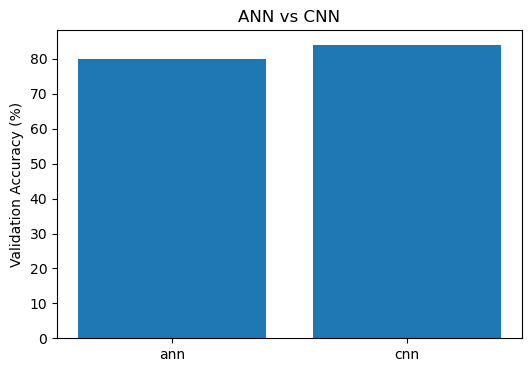

In [ ]:
# Validation Accuracy Comparison

plt.figure(figsize=(6,4))

plt.bar(
    default_df["Model"],
    default_df["Validation Accuracy"]
)

plt.ylabel("Validation Accuracy (%)")
plt.title("ANN vs CNN")

plt.show()

In [ ]:
## Conclusion

ann_acc = default_df[
    default_df["Model"]=="ann"
]["Validation Accuracy"].values[0]

cnn_acc = default_df[
    default_df["Model"]=="cnn"
]["Validation Accuracy"].values[0]

print(f"ANN Validation Accuracy : {ann_acc}%")
print(f"CNN Validation Accuracy : {cnn_acc}%")

print(f"Improvement : {cnn_acc-ann_acc:.2f}%")

ANN Validation Accuracy : 80.0%
CNN Validation Accuracy : 84.0%
Improvement : 4.00%


##### Conclusion:

CNN achieved higher validation accuracy than ANN.

ANN Validation Accuracy = 80%

CNN Validation Accuracy = 84%

The CNN improved performance by 4%.

This indicates that CNN is better suited for image classification because it can automatically learn spatial features from images.

### Learning Rate Analysis

,Learning Rate,Train Accuracy,Validation Accuracy,Validation Loss
0,0.100,86.27,80.00,0.4358
1,0.010,86.27,80.00,0.4024
2,0.001,89.55,81.33,0.3954


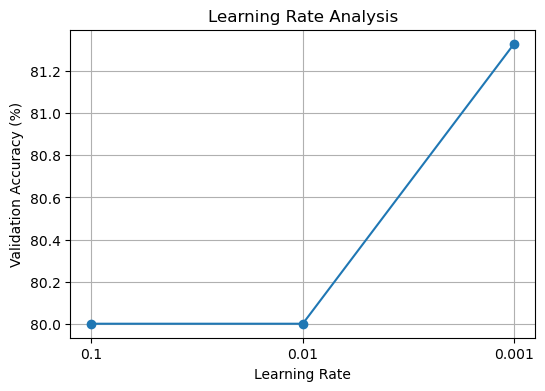

Best Learning Rate: 0.001


In [24]:
lr_df = df[df["Experiment"] == "lr_tuning"].copy()

display(
    lr_df[
        [
            "Learning Rate",
            "Train Accuracy",
            "Validation Accuracy",
            "Validation Loss"
        ]
    ].sort_values("Learning Rate", ascending=False)
)


plt.figure(figsize=(6,4))

plt.plot(
    lr_df["Learning Rate"].astype(str),
    lr_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate Analysis")
plt.grid(True)

plt.show()

best_lr = lr_df.loc[
    lr_df["Validation Accuracy"].idxmax(),
    "Learning Rate"
]

print(f"Best Learning Rate: {best_lr}")

### Dropout analysis

,Dropout,Train Accuracy,Validation Accuracy,Validation Loss
3,0.2,91.04,85.33,0.4036
4,0.3,89.85,81.33,0.3911
5,0.5,89.85,81.33,0.4631


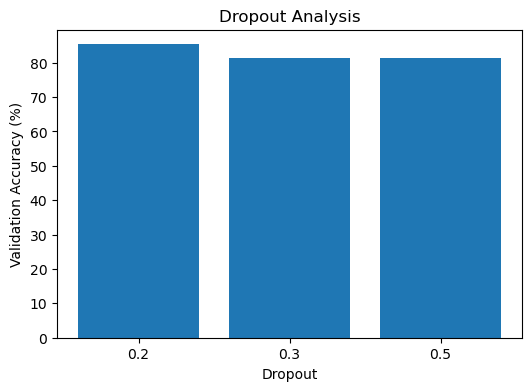

Best Dropout: 0.2


In [ ]:
drop_df = df[df["Experiment"] == "dropout_tuning"].copy()

display(
    drop_df[
        [
            "Dropout",
            "Train Accuracy",
            "Validation Accuracy",
            "Validation Loss"
        ]
    ]
)

plt.figure(figsize=(6,4))

plt.bar(
    drop_df["Dropout"].astype(str),
    drop_df["Validation Accuracy"]
)

plt.xlabel("Dropout")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Analysis")

plt.show()

best_dropout = drop_df.loc[
    drop_df["Validation Accuracy"].idxmax(),
    "Dropout"
]

print(f"Best Dropout: {best_dropout}")

### Weight Decay Analysis

,Weight Decay,Train Accuracy,Validation Accuracy,Validation Loss
6,0.0000,91.04,84.0,0.4313
7,0.0001,91.04,84.0,0.4553
8,0.0010,91.64,84.0,0.4342


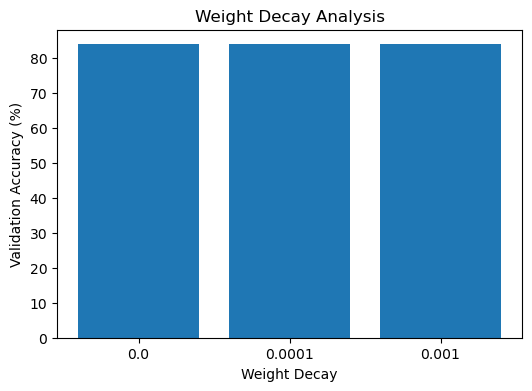

Best Weight Decay: 0.0


In [16]:
wd_df = df[df["Experiment"] == "weight_decay_tuning"].copy()

display(
    wd_df[
        [
            "Weight Decay",
            "Train Accuracy",
            "Validation Accuracy",
            "Validation Loss"
        ]
    ]
)

plt.figure(figsize=(6,4))

plt.bar(
    wd_df["Weight Decay"].astype(str),
    wd_df["Validation Accuracy"]
)

plt.xlabel("Weight Decay")
plt.ylabel("Validation Accuracy (%)")
plt.title("Weight Decay Analysis")

plt.show()

best_wd = wd_df.loc[
    wd_df["Validation Accuracy"].idxmax(),
    "Weight Decay"
]

print(f"Best Weight Decay: {best_wd}")

### Epoch analysis

,Epochs,Train Accuracy,Validation Accuracy,Validation Loss
9,5,88.66,81.33,0.3804
10,10,91.94,84.00,0.4243
11,15,91.94,84.00,0.5258


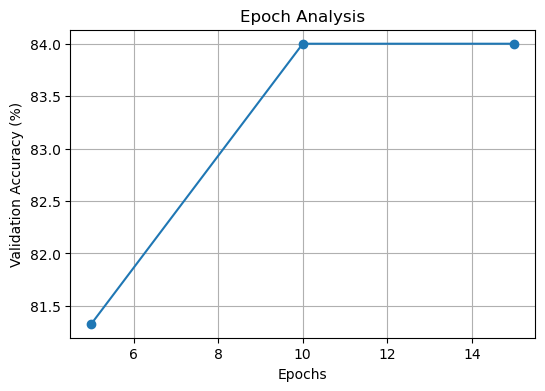

Best Epochs: 10


In [17]:
epoch_df = df[df["Experiment"] == "epoch_tuning"].copy()

display(
    epoch_df[
        [
            "Epochs",
            "Train Accuracy",
            "Validation Accuracy",
            "Validation Loss"
        ]
    ]
)

plt.figure(figsize=(6,4))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Validation Accuracy"],
    marker="o"
)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.title("Epoch Analysis")
plt.grid(True)

plt.show()

best_epoch = epoch_df.loc[
    epoch_df["Validation Accuracy"].idxmax(),
    "Epochs"
]

print(f"Best Epochs: {best_epoch}")

### Optimizer analysis

,Optimizer,Train Accuracy,Validation Accuracy,Validation Loss
12,adam,93.13,85.33,0.612
13,sgd,86.27,80.00,0.430
14,rmsprop,92.84,86.67,0.412


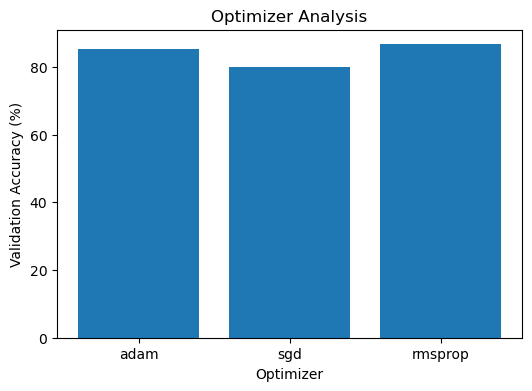

Best Optimizer: rmsprop


In [18]:
opt_df = df[df["Experiment"] == "optimizer_tuning"].copy()

display(
    opt_df[
        [
            "Optimizer",
            "Train Accuracy",
            "Validation Accuracy",
            "Validation Loss"
        ]
    ]
)

plt.figure(figsize=(6,4))

plt.bar(
    opt_df["Optimizer"],
    opt_df["Validation Accuracy"]
)

plt.xlabel("Optimizer")
plt.ylabel("Validation Accuracy (%)")
plt.title("Optimizer Analysis")

plt.show()

best_optimizer = opt_df.loc[
    opt_df["Validation Accuracy"].idxmax(),
    "Optimizer"
]

print(f"Best Optimizer: {best_optimizer}")

The best performing model was the CNN trained with RMSprop optimizer.

Configuration:
- Optimizer: RMSprop
- Learning Rate: 0.001
- Dropout: 0.3
- Weight Decay: 0.0001
- Epochs: 10

This model achieved the highest validation accuracy of 86.67%,